In [3]:
import pandas as pd
import os
from glob import glob

In [119]:
# Load the data
answer_dir = 'answers'
csv_files = glob(os.path.join(answer_dir, '*.csv'))
# format of name of the file is Humanoid Control_ Video Comparisons form{form_num} finally (Responses) - Form Responses
csv_files = {f.split('Humanoid Control_ Video Comparisons ')[1].split(' finally')[0]: f for f in csv_files}

# load the shuffled_labels
final_human_study_dir = 'final_human_study'
shuffled_labels = glob(os.path.join(final_human_study_dir, 'shuffled_labels*.csv'))
shuffled_labels = {f.split('shuffled_labels_')[1].split('.csv')[0]: f for f in shuffled_labels}
shuffled_labels_form_names = {
    'form1': 'form0',
    'form2': 'form1',
    'form3': 'form2',
}
all_data = {form_name: {'answers': pd.read_csv(csv_files[form_name]),
                        'shuffled_labels': preprocess_shuffled_labels(
                            pd.read_csv(shuffled_labels[shuffled_labels_form_names[form_name]]))} for
            form_name in csv_files.keys()}

In [120]:
def preprocess_shuffled_labels(df):
    df_new = df.copy()
    df_new['algorithms'] = df_new['algorithms'].map(lambda x: eval(x))
    df_new['labels'] = df_new['labels'].map(lambda x: eval(x))
    df_new['video_paths'] = df_new['video_paths'].map(lambda x: eval(x))
    return df_new

In [121]:
def map_labels_to_algorithms(answers_df, mapping_df):
    # map the labels to the algorithms
    answers_df = all_data['form1']['answers']
    mapping_df = all_data['form1']['shuffled_labels']
    # Extract only the answer columns
    answer_columns = [col for col in answers_df.columns if col.startswith('Q')]

    # Map answers back to algorithms based on the corresponding row in mapping_df
    mapped_answers = []
    for col_idx, column in enumerate(answer_columns):
        env = mapping_df.iloc[col_idx]['env']
        algorithms = mapping_df.iloc[col_idx]['algorithms']
        labels = mapping_df.iloc[col_idx]['labels']

        for _, row in answers_df.iterrows():
            choice = row[column]
            winner_alg = algorithms[labels.index(choice)] if choice in labels else None
            mapped_answers.append({
                'Timestamp': row['Timestamp'],
                'Environment': env,
                'Question': column,
                'Choice': choice,
                'Algorithm': winner_alg
            })

    # Create intermediate DataFrame
    mapped_answers_df = pd.DataFrame(mapped_answers)
    return mapped_answers_df

In [122]:
all_answers = []
for form_name, data in all_data.items():
    mapped_answers = map_labels_to_algorithms(data['answers'], data['shuffled_labels'])
    mapped_answers['form_name'] = form_name
    all_answers.append(mapped_answers)
all_answers = pd.concat(all_answers)
all_answers

,Timestamp,Environment,Question,Choice,Algorithm,form_name
0,2/26/2025 9:22:50,steering,Q 1: Which example looks more human-like for t...,B,PULSE,form1
1,2/26/2025 10:14:53,steering,Q 1: Which example looks more human-like for t...,B,PULSE,form1
2,2/26/2025 9:22:50,steering,Q 2: Which example looks more human-like for t...,C,MaskedMimic_Inversion_Prior_True,form1
3,2/26/2025 10:14:53,steering,Q 2: Which example looks more human-like for t...,C,MaskedMimic_Inversion_Prior_True,form1
4,2/26/2025 9:22:50,steering,Q 3: Which example looks more human-like for t...,C,MaskedMimic_Inversion_Prior_True,form1
...,...,...,...,...,...,...
75,2/26/2025 10:14:53,long_jump,Q 38: Which example looks more human-like for ...,C,PULSE,form1
76,2/26/2025 9:22:50,long_jump,Q 39: Which example looks more human-like for ...,B,PULSE,form1
77,2/26/2025 10:14:53,long_jump,Q 39: Which example looks more human-like for ...,B,PULSE,form1
78,2/26/2025 9:22:50,long_jump,Q 40: Which example looks more human-like for ...,C,PULSE,form1


<AxesSubplot: ylabel='count'>

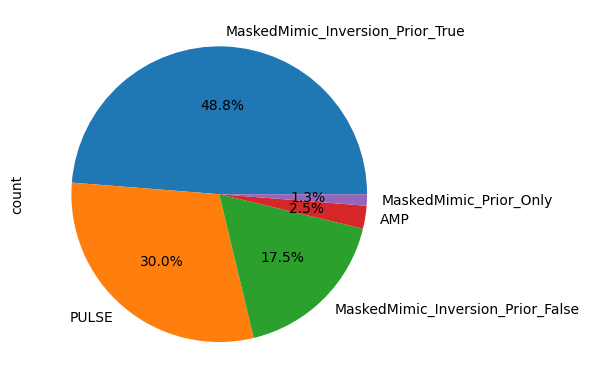

In [136]:
all_answers['Algorithm'].value_counts().T.plot(kind='pie', autopct='%1.1f%%')

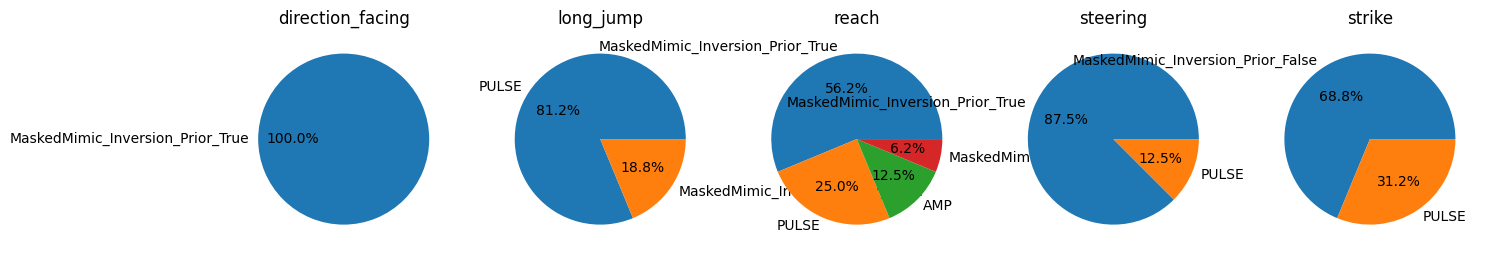

In [140]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=len(all_answers['Environment'].unique()), figsize=(16, 16))

for ax, (env, group) in zip(axes, all_answers.groupby('Environment')):
    group['Algorithm'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax)
    ax.set_title(env)
    ax.set_ylabel('')
plt.show()